# Projet — Classification de sons urbains (UrbanSound8K)

Le dataset **UrbanSound8K** contient **8 732 fichiers audio** répartis en **10 classes** de sons urbains courants (klaxons, sirènes, aboiements, etc.).
Chaque extrait dure au maximum 4 secondes, à des taux d'échantillonnage variables.

Contrairement à ESC-50, le dataset couvre toutes ses classes — il n'y a pas de sous-ensemble à filtrer.
Le protocole officiel définit **10 folds** de validation croisée ; ici on utilise le **fold 10 comme test** et les folds 1–9 comme entraînement.

## Imports

On importe les bibliothèques nécessaires :
- **pandas** : chargement et manipulation des métadonnées (fichier CSV)
- **librosa** : chargement des fichiers audio et calcul de spectrogrammes
- **matplotlib** : visualisation des spectrogrammes
- **pathlib** : gestion des chemins de fichiers

In [1]:
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Chargement des métadonnées

Le fichier `UrbanSound8K.csv` décrit chaque échantillon audio avec les colonnes suivantes :
- **slice_file_name** : nom du fichier WAV
- **fold** : numéro de pli (1–10) utilisé pour la validation croisée
- **classID** : identifiant numérique de la classe (0–9)
- **class** : nom de la classe (ex. `dog_bark`, `siren`)

Les fichiers audio sont organisés dans des sous-dossiers `audio/fold{1..10}/`.

In [2]:
META_PATH = Path("metadata/UrbanSound8K.csv")
AUDIO_DIR = Path("audio")

df = pd.read_csv(META_PATH)

print(f"Échantillons total : {len(df)}")
print(f"Nombre de classes  : {df['class'].nunique()}")
print(f"Classes            : {sorted(df['class'].unique())}")
print(f"Folds disponibles  : {sorted(df['fold'].unique())}")
df.head()

Échantillons total : 8732
Nombre de classes  : 10
Classes            : ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']
Folds disponibles  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


## Spectrogramme Mel

Pour traiter l'audio avec un réseau de neurones, on convertit chaque fichier sonore en une **image 2D** appelée spectrogramme Mel.

Le principe :
1. On applique une **transformée de Fourier à court terme** (STFT) pour découper le signal en fenêtres temporelles et obtenir le contenu fréquentiel à chaque instant.
2. On projette les fréquences sur l'**échelle Mel**, qui imite la perception humaine (les basses fréquences ont plus de résolution que les hautes).
3. On convertit les amplitudes en **décibels** (échelle logarithmique) pour que les valeurs soient plus stables à l'entraînement.

Particularité d'UrbanSound8K : les extraits ont des **durées variables** (≤ 4 s). On fixe une longueur cible de **4 secondes** ; les signaux plus courts sont complétés par des zéros (*zero-padding*), les plus longs sont tronqués. Cela garantit que tous les spectrogrammes ont la même forme `(128, 173)` — 173 trames ≈ 4 s à `sr=22050` et `hop_length=512`.

Paramètres :
- `sr=22050` : fréquence d'échantillonnage cible
- `duration=4.0` : durée fixe en secondes
- `n_mels=128` : nombre de bandes Mel
- `hop_length=512` : décalage entre deux fenêtres consecutives

In [3]:
SR         = 22050
DURATION   = 4.0
N_MELS     = 128
HOP_LENGTH = 512
N_FRAMES   = int(SR * DURATION / HOP_LENGTH) + 1  # 173


def load_spectrogram(fold, filename):
    """Charge un fichier WAV et retourne son spectrogramme Mel en dB (128 × 173)."""
    path = AUDIO_DIR / f"fold{fold}" / filename
    signal, _ = librosa.load(path, sr=SR, duration=DURATION)

    # Padding si le signal est plus court que DURATION
    target_len = int(SR * DURATION)
    if len(signal) < target_len:
        signal = librosa.util.fix_length(signal, size=target_len)

    mel = librosa.feature.melspectrogram(
        y=signal, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=mel.max())
    return mel_db


# Test sur un fichier
sample = df.iloc[0]
spec = load_spectrogram(sample["fold"], sample["slice_file_name"])
print(f"Forme du spectrogramme : {spec.shape}  (n_mels × trames temporelles)")
print(f"Classe                 : {sample['class']}")

d:\Projets\Code\IIM\cours_ia_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Forme du spectrogramme : (128, 173)  (n_mels × trames temporelles)
Classe                 : dog_bark


## Visualisation

On visualise 9 exemples tirés aléatoirement pour comprendre à quoi ressemblent les données.
Chaque spectrogramme est affiché avec sa classe et le nom du fichier correspondant.

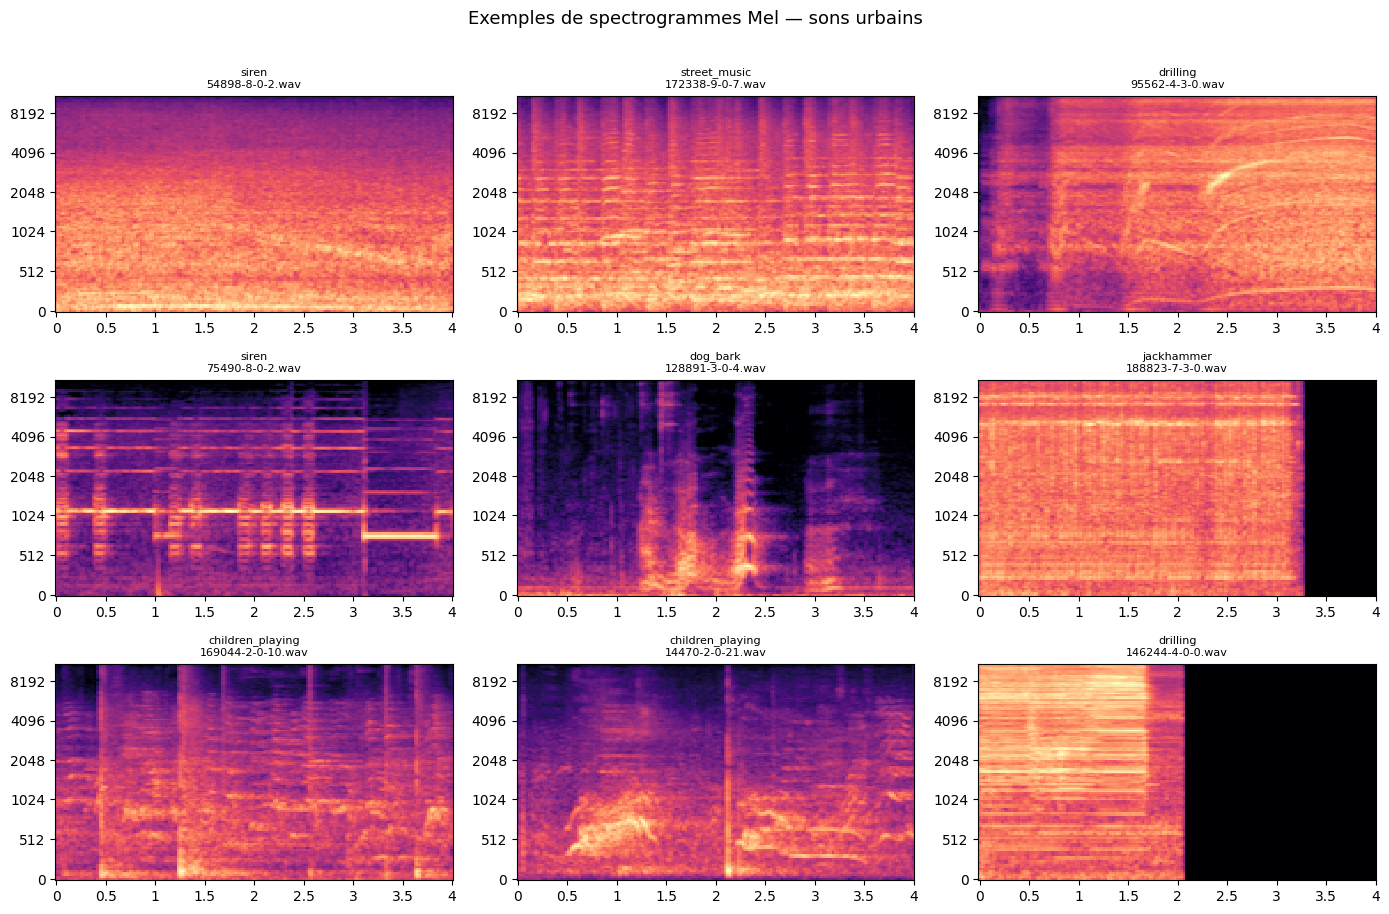

In [4]:
samples = df.sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    spec = load_spectrogram(row["fold"], row["slice_file_name"])
    librosa.display.specshow(
        spec, sr=SR, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", ax=ax, cmap="magma"
    )
    ax.set_title(f"{row['class']}\n{row['slice_file_name']}", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Exemples de spectrogrammes Mel — sons urbains", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Dataset et DataLoader

Pour entraîner un réseau PyTorch, on encapsule les données dans une classe `Dataset` qui gère le chargement à la volée de chaque échantillon. Le `DataLoader` s'appuie ensuite sur cette classe pour construire des **mini-batches** et les mélanger à chaque époque.

**Découpage train / test :** UrbanSound8K définit 10 folds de validation croisée. On utilise le **fold 10 comme ensemble de test** (~873 échantillons) et les folds 1–9 comme entraînement (~7 859 échantillons), conformément au protocole officiel.

La méthode `__getitem__` charge le spectrogramme et ajoute une dimension de canal pour obtenir un tenseur de forme `(1, 128, 173)` — équivalent à une image en niveaux de gris que le CNN peut traiter directement.

Le mapping classe→indice est construit à partir des `classID` du CSV pour rester cohérent avec les labels officiels (0–9).

In [5]:
class UrbanSoundDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = load_spectrogram(row["fold"], row["slice_file_name"])  # (128, 173)
        x = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)      # (1, 128, 173)
        y = int(row["classID"])
        return x, y


df_train = df[df["fold"] != 10]
df_test  = df[df["fold"] == 10]

train_dataset = UrbanSoundDataset(df_train)
test_dataset  = UrbanSoundDataset(df_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

x_batch, y_batch = next(iter(train_loader))
print(f"Train : {len(train_dataset)} échantillons  |  Test : {len(test_dataset)} échantillons")
print(f"Forme d'un batch : {x_batch.shape}  →  labels : {y_batch.shape}")

Train : 7895 échantillons  |  Test : 837 échantillons
Forme d'un batch : torch.Size([64, 1, 128, 173])  →  labels : torch.Size([64])


## Création du CNN

Les spectrogrammes Mel sont des images 2D de taille `(1, 128, 173)` — on peut donc y appliquer exactement les mêmes convolutions que sur des images classiques.

L'architecture utilise **3 blocs convolutifs** successifs, chacun composé de :
- `Conv2d` : détecte des motifs locaux (bords, textures fréquentielles)
- `BatchNorm2d` : normalise les activations pour stabiliser l'entraînement
- `ReLU` : introduit la non-linéarité
- `MaxPool2d(2, 2)` : divise la résolution spatiale par 2

Après les convolutions, un **classifieur entièrement connecté** produit un score par classe.

```
Entrée : (1, 128, 173)
  → conv_block1 : Conv2d(1→32)   + BN + ReLU + MaxPool  →  (32,  64, 86)
  → conv_block2 : Conv2d(32→64)  + BN + ReLU + MaxPool  →  (64,  32, 43)
  → conv_block3 : Conv2d(64→128) + BN + ReLU + MaxPool  → (128,  16, 21)
  → Flatten → Linear(43008→256) → ReLU → Dropout(0.5) → Linear(256→10)
```

In [6]:
class CNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 21, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.conv_block1(x)   # (B,  32,  64,  86)
        x = self.conv_block2(x)   # (B,  64,  32,  43)
        x = self.conv_block3(x)   # (B, 128,  16,  21)
        x = self.classifier(x)    # (B,  10)
        return x


cnn = CNN().to(device)

n_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {n_params:,}")

x_dummy = torch.randn(1, 1, 128, 173).to(device)
out = cnn(x_dummy)
print(f"Forward pass : entrée {tuple(x_dummy.shape)} → sortie {tuple(out.shape)}")

Paramètres entraînables : 11,105,994
Forward pass : entrée (1, 1, 128, 173) → sortie (1, 10)


## Entraînement

L'entraînement repose sur les mêmes éléments que dans les ateliers précédents :

- **`CrossEntropyLoss`** : mesure l'écart entre les scores prédits et la vraie classe. C'est la fonction de perte standard pour la classification multi-classes.
- **`AdamW`** (lr=1e-3) : optimiseur adaptatif qui met à jour les poids à chaque batch en suivant le gradient.
- **`ReduceLROnPlateau`** : réduit le taux d'apprentissage d'un facteur 0.5 si la loss de validation ne s'améliore pas pendant 3 époques consécutives.
- **Early stopping** (patience=5) : arrête l'entraînement si aucune amélioration n'est constatée pendant 5 époques, et restaure les meilleurs poids.
- **`SummaryWriter`** : enregistre les métriques pour TensorBoard (`tensorboard --logdir runs/`).

In [7]:
def train_loop(dataloader, model, loss_fn, optimizer, writer, epoch):
    model.train()
    pbar = tqdm(dataloader, desc="Train")
    for batch, (x, y_true) in enumerate(pbar):
        x, y_true = x.to(device), y_true.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred, y_true)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        pbar.set_postfix(loss=f"{loss.item():.4f}")
        writer.add_scalar("Loss/train", loss.item(), epoch * len(dataloader) + batch)


def test_loop(dataloader, model, loss_fn, optimizer, writer, epoch):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for x, y_true in tqdm(dataloader, desc="Test "):
            x, y_true = x.to(device), y_true.to(device)
            y_pred = model(x)
            test_loss += loss_fn(y_pred, y_true).item()
            correct += (y_pred.argmax(1) == y_true).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Accuracy : {100 * correct:.1f}%  |  Avg loss : {test_loss:.6f}")

    writer.add_scalar("Loss/test", test_loss, epoch)
    writer.add_scalar("Accuracy/test", 100 * correct, epoch)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

    return test_loss

In [8]:
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.AdamW(cnn.parameters(), lr=1e-3)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
writer     = SummaryWriter("runs/cnn_urban_sound_8k")

epochs      = 30
es_patience = 5

best_loss   = float("inf")
best_weights = None
epochs_without_improvement = 0

for t in range(epochs):
    print(f"Epoch : {t+1}  |  lr = {optimizer.param_groups[0]['lr']:.2e}")
    train_loop(train_loader, cnn, criterion, optimizer, writer, t)
    val_loss = test_loop(test_loader, cnn, criterion, optimizer, writer, t)

    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        best_weights = {k: v.cpu().clone() for k, v in cnn.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"  (pas d'amélioration depuis {epochs_without_improvement} époque(s))")
        if epochs_without_improvement >= es_patience:
            print(f"Early stopping déclenché à l'époque {t+1}.")
            break

cnn.load_state_dict(best_weights)
print("Entraînement terminé.")

Epoch : 1  |  lr = 1.00e-03


Test : 100%|██████████| 14/14 [00:05<00:00,  2.79it/s]


Accuracy : 34.1%  |  Avg loss : 1.693660
Epoch : 2  |  lr = 1.00e-03


Test : 100%|██████████| 14/14 [00:04<00:00,  2.85it/s]


Accuracy : 43.4%  |  Avg loss : 1.446055
Epoch : 3  |  lr = 1.00e-03


...

Accuracy : 71.3%  |  Avg loss : 0.922261
  (pas d'amélioration depuis 3 époque(s))
Epoch : 17  |  lr = 1.00e-03


Test : 100%|██████████| 14/14 [00:05<00:00,  2.76it/s]


Accuracy : 70.5%  |  Avg loss : 1.002297
  (pas d'amélioration depuis 4 époque(s))
Epoch : 18  |  lr = 5.00e-04


Test : 100%|██████████| 14/14 [00:05<00:00,  2.76it/s]

Accuracy : 74.3%  |  Avg loss : 0.864109
  (pas d'amélioration depuis 5 époque(s))
Early stopping déclenché à l'époque 18.
Entraînement terminé.


## Évaluation finale

On calcule la **matrice de confusion** et les **métriques par classe** (precision, recall, F1) sur l'ensemble de test pour identifier les classes bien reconnues et celles qui posent problème.

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

CLASS_NAMES = [
    "air_conditioner", "car_horn", "children_playing", "dog_bark",
    "drilling", "engine_idling", "gun_shot", "jackhammer",
    "siren", "street_music"
]

cnn.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y_true in test_loader:
        x = x.to(device)
        y_pred = cnn(x).argmax(1).cpu()
        all_preds.extend(y_pred.tolist())
        all_labels.extend(y_true.tolist())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion — UrbanSound8K (fold 10)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
writer.add_figure("Confusion Matrix", fig)
plt.show()

writer.close()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

                  precision    recall  f1-score   support

 air_conditioner       0.62      0.64      0.63       100
        car_horn       0.88      0.85      0.86        33
children_playing       0.51      0.75      0.61       100
        dog_bark       0.85      0.63      0.72       100
        drilling       0.75      0.71      0.73       100
   engine_idling       0.91      0.42      0.57        93
        gun_shot       0.94      0.97      0.95        32
      jackhammer       0.75      0.95      0.83        96
           siren       0.77      0.59      0.67        83
    street_music       0.69      0.85      0.76       100

        accuracy                           0.71       837
       macro avg       0.76      0.74      0.73       837
    weighted avg       0.74      0.71      0.71       837



## Export ONNX

**ONNX** (Open Neural Network Exchange) est un format ouvert qui permet de déployer un modèle PyTorch dans n'importe quel environnement compatible : moteurs d'inférence haute performance (ONNX Runtime, TensorRT), applications mobiles, navigateurs (via ONNX.js), etc.

L'export fonctionne par **traçage** : PyTorch effectue un forward pass avec un tenseur factice (*dummy input*) et enregistre toutes les opérations dans un graphe statique.

Points clés :
- Le modèle doit être en mode **`eval()`** avant l'export pour désactiver Dropout et BatchNorm en mode entraînement.
- `input_names` et `output_names` donnent des noms lisibles aux entrées/sorties du graphe.
- `dynamic_axes` permet d'accepter des batches de taille variable à l'inférence (`batch_size` n'est pas fixé dans le graphe).
- `opset_version=17` cible une version ONNX récente et largement supportée.

In [10]:
import torch
from pathlib import Path

ONNX_DIR  = Path("onnx")
ONNX_DIR.mkdir(exist_ok=True)
ONNX_PATH = ONNX_DIR / "cnn_urban_sound_8k.onnx"

cnn.eval()

dummy_input = torch.randn(1, 1, 128, 173).to(device)

torch.onnx.export(
    cnn,
    dummy_input,
    str(ONNX_PATH),
    opset_version=17,
    input_names=["spectrogram"],
    output_names=["logits"],
    dynamic_axes={
        "spectrogram": {0: "batch_size"},
        "logits":      {0: "batch_size"},
    },
)

print(f"Modèle exporté : {ONNX_PATH}")

C:\Users\arnau\AppData\Local\Temp\ipykernel_14144\409460657.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0611 12:27:40.259000 14144 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0611 12:27:40.905000 14144 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\arnau\AppData\Local\Python\pythoncore-3.14-64\Lib\copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Modèle exporté : onnx\cnn_urban_sound_8k.onnx
